In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("../data/cleaned_superstore.csv")

df.head()

,Order ID,Customer Name,Category,Sales,Quantity,Profit,Region,Order Date
0,O001,Rahul,Furniture,5000,2,800,South,2024-01-05
1,O002,Priya,Technology,12000,1,2500,East,2024-01-08
2,O003,Arjun,Office Supplies,800,4,120,West,2024-01-10
3,O004,Sneha,Furniture,3000,3,450,North,2024-01-12
4,O005,Ravi,Technology,9500,2,1800,South,2024-01-15


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 5
Columns: 8
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Order ID       5 non-null      str  
 1   Customer Name  5 non-null      str  
 2   Category       5 non-null      str  
 3   Sales          5 non-null      int64
 4   Quantity       5 non-null      int64
 5   Profit         5 non-null      int64
 6   Region         5 non-null      str  
 7   Order Date     5 non-null      str  
dtypes: int64(3), str(5)
memory usage: 452.0 bytes


In [4]:
df.describe()

,Sales,Quantity,Profit
count,5.000000,5.000000,5.000000
mean,6060.000000,2.400000,1134.000000
std,4617.141973,1.140175,989.585772
min,800.000000,1.000000,120.000000
25%,3000.000000,2.000000,450.000000
50%,5000.000000,2.000000,800.000000
75%,9500.000000,3.000000,1800.000000
max,12000.000000,4.000000,2500.000000


In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Order Date"].head()

0   2024-01-05
1   2024-01-08
2   2024-01-10
3   2024-01-12
4   2024-01-15
Name: Order Date, dtype: datetime64[us]

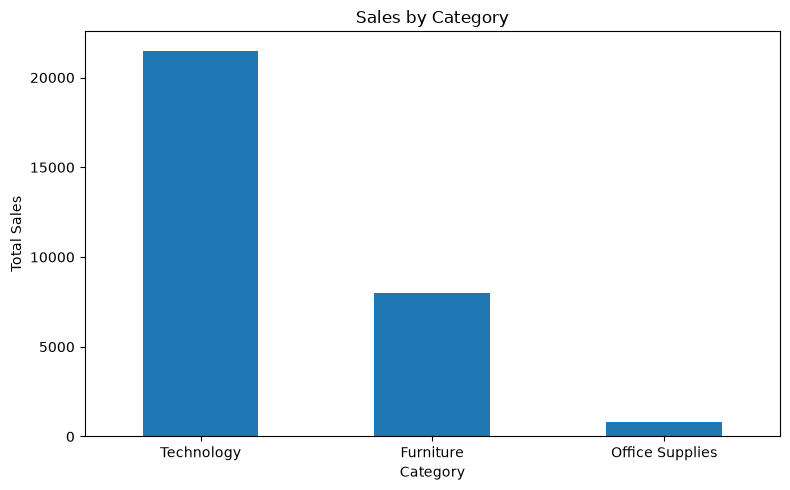

In [7]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/sales_by_category.png")
plt.show()

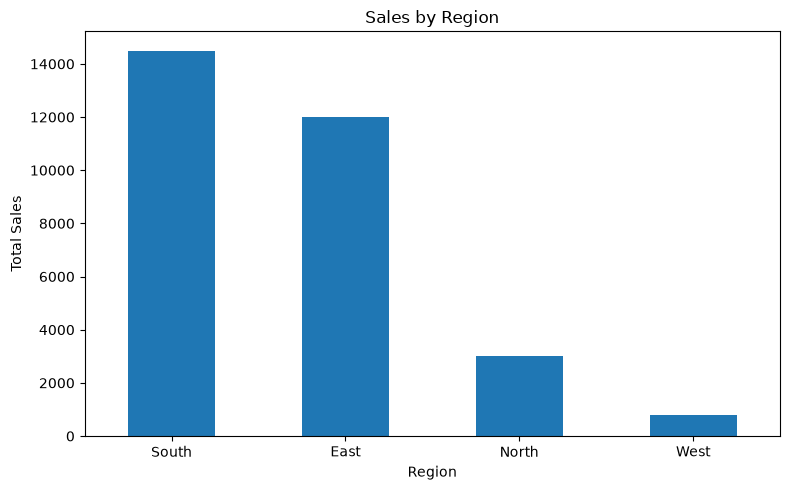

In [8]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/sales_by_region.png")
plt.show()

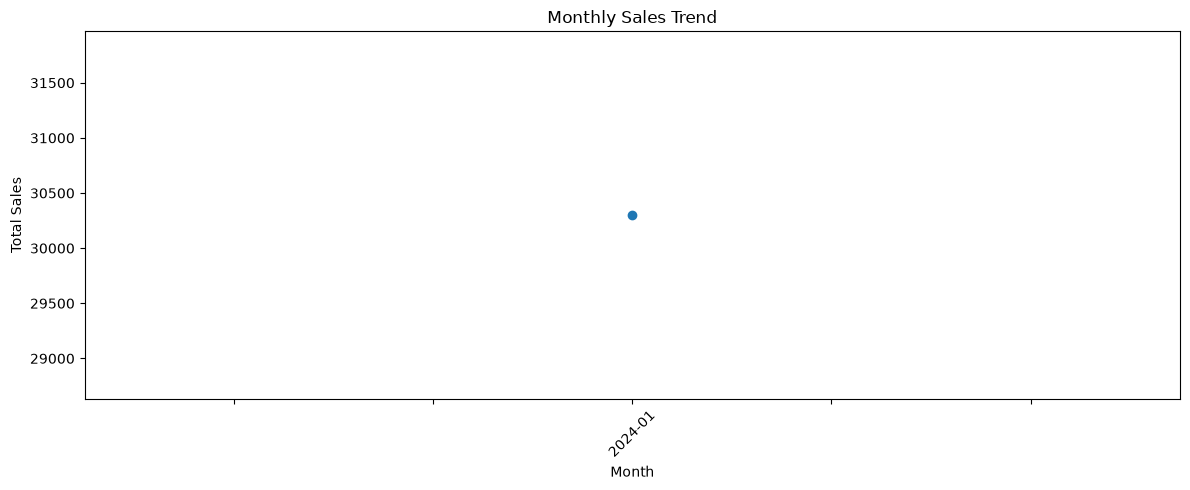

In [9]:
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visualizations/monthly_sales.png")
plt.show()

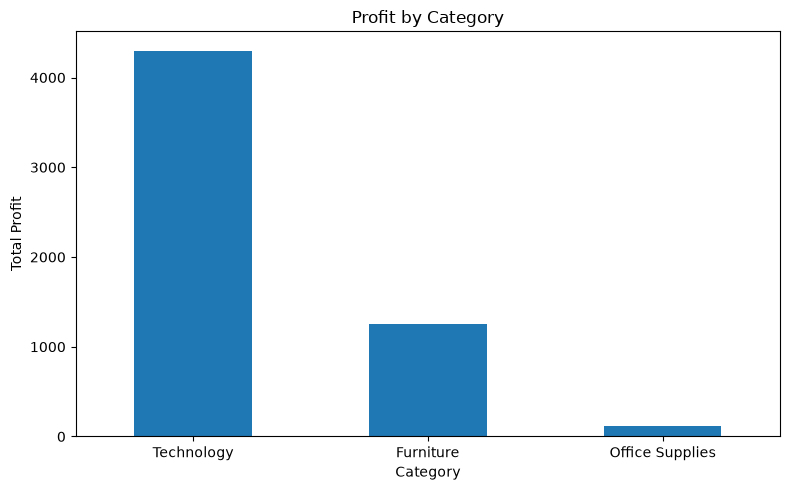

In [10]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/profit_by_category.png")
plt.show()

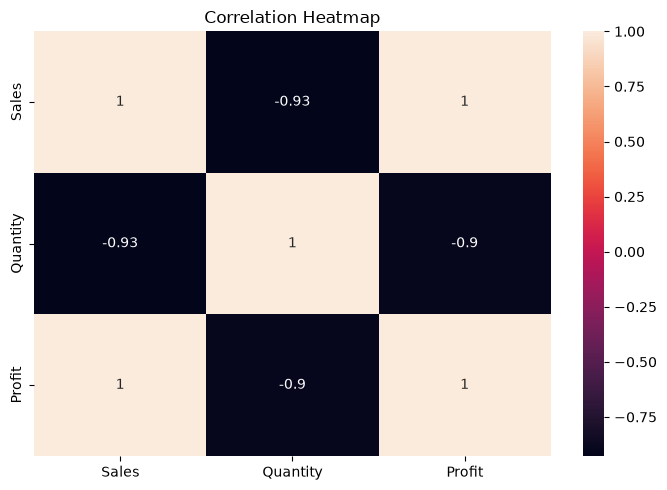

In [11]:
numeric_cols = ["Sales", "Quantity", "Profit"]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig("../visualizations/correlation_heatmap.png")
plt.show()

In [12]:
fig = px.bar(
    df.groupby("Category", as_index=False)["Sales"].sum(),
    x="Category",
    y="Sales",
    title="Interactive Sales by Category"
)

fig.show()

In [13]:
fig.write_html("../visualizations/interactive_sales.html")